<a href="https://colab.research.google.com/github/Krimaxev/Data_Visualisation_Methods_ITMO/blob/main/labs/%D0%9B%D0%A03_%D0%9E%D0%B1%D0%B5%D1%81%D0%BF%D0%B5%D1%87%D0%B5%D0%BD%D0%B8%D0%B5_%D0%BA%D0%B0%D1%87%D0%B5%D1%81%D1%82%D0%B2%D0%B0_%D0%B4%D0%B0%D0%BD%D0%BD%D1%8B%D1%85.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Постановка задачи


**Цель работы:** исследование и обработка данных для повышения их качества.

**Краткое описание:** в лабораторной работе приводится поэтапный план изучения и обработки намеренно не предобработанных данных. Необходимо выполнить все этапы плана и оценить результаты преобразований.

# Данные



В папке [Data/lab3](https://drive.google.com/drive/folders/1437z7m5Ut4WUJOhJg1oZz13dtBpxgFKs?usp=share_link) расположена таблица `monster_com_job_sample.com` с данными о вакансиях. Также эти данные с описанием и примерами обработки можно найти на [kaggle](https://www.kaggle.com/code/ankkur13/perfect-dataset-to-get-the-hands-dirty/data#).

##### **Формат данных**

```
country,country_code,date_added,has_expired,job_board,job_description,job_title,job_type,location,organization,page_url,salary,sector,uniq_id
United States of America,US,"",No,jobs.monster.com,"TeamSoft is seeing an IT Support Specialist to join our client in Madison, WI. The ideal candidate must have at least 6 years of experience in the field. They need to be familiar with a variety of the field's concepts, practices, and procedures as this position relies on extensive experience and judgment to plan and accomplish goals. Required Skills:вАҐ Call tracking softwareвАҐ Phone based technical supportвАҐ Problem documentation and communicationвАҐ Remote Desktop Management ToolsвАҐ Respond to customer requestsвАҐ General understanding of LANDeskвАҐ Microsoft Office 2007 SuiteFind out why TeamSoft is the Madison area's technology leader with over 200 IT consultants. Owned, operated, and managed by IT consultants, TeamSoft is the clear choice for your career. Join the TeamSoft family today!Did you know?вАҐ TeamSoft offers salaried options for many positions that include 5 weeks PTO and great benefits!вАҐ TeamSoft has been in business since 1996вАҐ TeamSoft's owners are local IT professionals who possess a wealth of experience in application development, business analysis, and project managementвАҐ TeamSoft's Recruiters are knowledgeable, friendly, and ready to help you make your next great career moveвАҐ TeamSoft offers a full benefits suite to all of our W2 consultants, including a 401k plan with a 100% vested 4% dollar for dollar matchвАҐ Our targeted selection process is designed to get to know your strengths and career interests and provide you with the best chance for success in your new positionвАҐ Our longest running consultant has been with us for 16 yearsвАҐ Consultants can participate in our charitable giving committee. To date, TeamSoft's charitable giving committee has donated over $100,000!TeamSoft is owned by local IT professionals. Our team also has deep experience with IT staffing. Our clients understand this and rely on our expertise. That is why TeamSoft is the Madison Area's largest privately owned IT consulting firm, with more than 200 current consultants! With over 50 active clients, TeamSoft will give you the greatest exposure to the widest range of IT careers.Our owners possess a combined 60+ years of IT consulting experience. Our recruiting and Account Management staff are very well-versed in our client markets. We get you. We know you. We know what you do every day. And we know what you deal with on the job.You take your career seriously and so do we. At TeamSoft you are not just a resume or number. Our goal is to create long-term partnerships with each of our consultants, and according to feedback from many of them, we are very good at this. Click HERE to see what our consultants have to say about working with TeamSoft.TeamSoft -- Promote yourself!TeamSoft is an equal employment opportunity employer functioning under an Affirmative Action Plan.",IT Support Technician Job in Madison,Full Time Employee,"Madison, WI 53702","",http://jobview.monster.com/it-support-technician-job-madison-wi-us-167855963.aspx?mescoid=1500134001001&jobPosition=20,"",IT/Software Development,11d599f229a80023d2f40e7c52cd941e
United States of America,US,"",No,jobs.monster.com,"The Wisconsin State Journal is seeking a flexible and motivated reporter/editor to lead its three-person business desk. WeвАЩre looking for an experienced journalist able to spot trends, be a watchdog and reflect the Madison areaвАЩs vibrant entrepreneurial community. This is a hybrid reporting and editing position that calls for a fleet-footed, multimedia storyteller able to maximize the newspaperвАЩs online presentation while also editing two sections a week. Candidates must have strong news judgment, be well versed in business news and trends and be able to quickly prioritize coverage.At least five yearsвАЩ experience reporting or editing for digital and print platforms desired. To be considered for the position, applicants must apply online.¬†As part of your online application, please attach five samples of your work or links to five recent stories.Wisconsin State Journal, 1901 Fish Hatchery Road, Madison, WI 53713Affirmative Action/Equal Opportunity Employer/Pre-employment drug testing appliesPI94338362Apply Here",Business Reporter/Editor Job in Madison,Full Time,"Madison, WI 53708",Printing and Publishing,http://jobview.monster.com/business-reporter-editor-job-madison-wi-us-167830105.aspx?mescoid=2700437001001&jobPosition=7,"","",e4cbb126dabf22159aff90223243ff2a
...
```

##### **Описание полей**
 - ```country``` — наименование страны;
 - ```country_code``` — код страны;
 - ```date_added``` — дата размещения вакансии;
 - ```has_expired``` — актуальность вакансии;
 - ```job_board``` — агрегатор вакансий, с которого собраны данные;
 - ```job_description``` — описание вакансии;
 - ```job_title``` — наименование должности;
 - ```job_type``` — вид занятости;
 - ```location``` — метоположение организации;
 - ```organization``` — наименование организации;
 - ```page_url``` — ссылка на страницу с вакансией;
 - ```salary``` — заработная плата;
 - ```sector``` — сфера деятельности;
 - ```uniq_id``` — уникальный идентификатор записи о вакансии.

# Понимание данных

In [3]:
import re
import numpy as np
import pandas as pd
import missingno as msno
from matplotlib import pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

В датасете есть несколько столбцов, в каждой ячейке которых записано одно и то же значение. Есть столбцы, в которых формат записи значений не стандартизирован. А есть такие, где указана информация, не соответствующая названию столбца.

**Первый этап изучения данных** – понять, какие основные проблемы предстоит решить для каждого из столбцов. Для этого загрузите датасет и выведите случайные несколько строк из него. Постарайтесь понять, что из себя представляют данные в столбцах.

In [4]:
from google.colab import files

uploaded = files.upload()

df = pd.read_csv("monster_com_job_sample.csv")

df.sample(5, random_state=42)

df.info()

Saving monster_com_job_sample.csv to monster_com_job_sample.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22000 entries, 0 to 21999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   country          22000 non-null  object
 1   country_code     22000 non-null  object
 2   date_added       122 non-null    object
 3   has_expired      22000 non-null  object
 4   job_board        22000 non-null  object
 5   job_description  22000 non-null  object
 6   job_title        22000 non-null  object
 7   job_type         20372 non-null  object
 8   location         22000 non-null  object
 9   organization     15133 non-null  object
 10  page_url         22000 non-null  object
 11  salary           3446 non-null   object
 12  sector           16806 non-null  object
 13  uniq_id          22000 non-null  object
dtypes: object(14)
memory usage: 2.3+ MB


**Задание**

Составьте таблицу, в которой будет содержаться название столбца, тип данных в нем и краткое описание проблем, которые вы заметили при первом взгляде на данные.


Название столбца | Тип данных | Проблемы
--- | --- | ---
```country``` |
```country_code``` |
```date_added``` |
```has_expired``` |
```job_board``` |
```job_description``` |
```job_title``` |
```job_type``` |
```location``` |
```organization``` |
```page_url``` |
```salary``` |
```sector``` |
```uniq_id``` |

### Оценка пустых ячеек в датасете

Выясните, в каких столбцах, строках и в каком количестве отсутствуют данные:
1. С помощью модуля `pandas` составьте таблицу, где каждому названию столбца будет сопоставлено общее количество ячеек и количество пустых ячеек.
2. Подсчитайте количество строк датасета, в которых пустыми являются более 75% ячеек.
3. Визуализируйте число пропусков в датасете с помощью модуля, построив столбчатую диаграмму. Для удобства можно воспользоваться модулем `missingno`.


In [5]:
# Таблица пропусков

missing_table = pd.DataFrame({
    "Общее количество ячеек": len(df),
    "Количество пустых ячеек": df.isna().sum(),
    "Процент пропусков": round(df.isna().mean() * 100, 2)
})

missing_table.sort_values(by="Количество пустых ячеек", ascending=False)

,Общее количество ячеек,Количество пустых ячеек,Процент пропусков
date_added,22000,21878,99.45
salary,22000,18554,84.34
organization,22000,6867,31.21
sector,22000,5194,23.61
job_type,22000,1628,7.40
country,22000,0,0.00
job_description,22000,0,0.00
job_board,22000,0,0.00
has_expired,22000,0,0.00
country_code,22000,0,0.00


Проверьте, как изменится размер датасета, если принять решение удалить все строки, где есть пустые значения. Сделайте выводы.

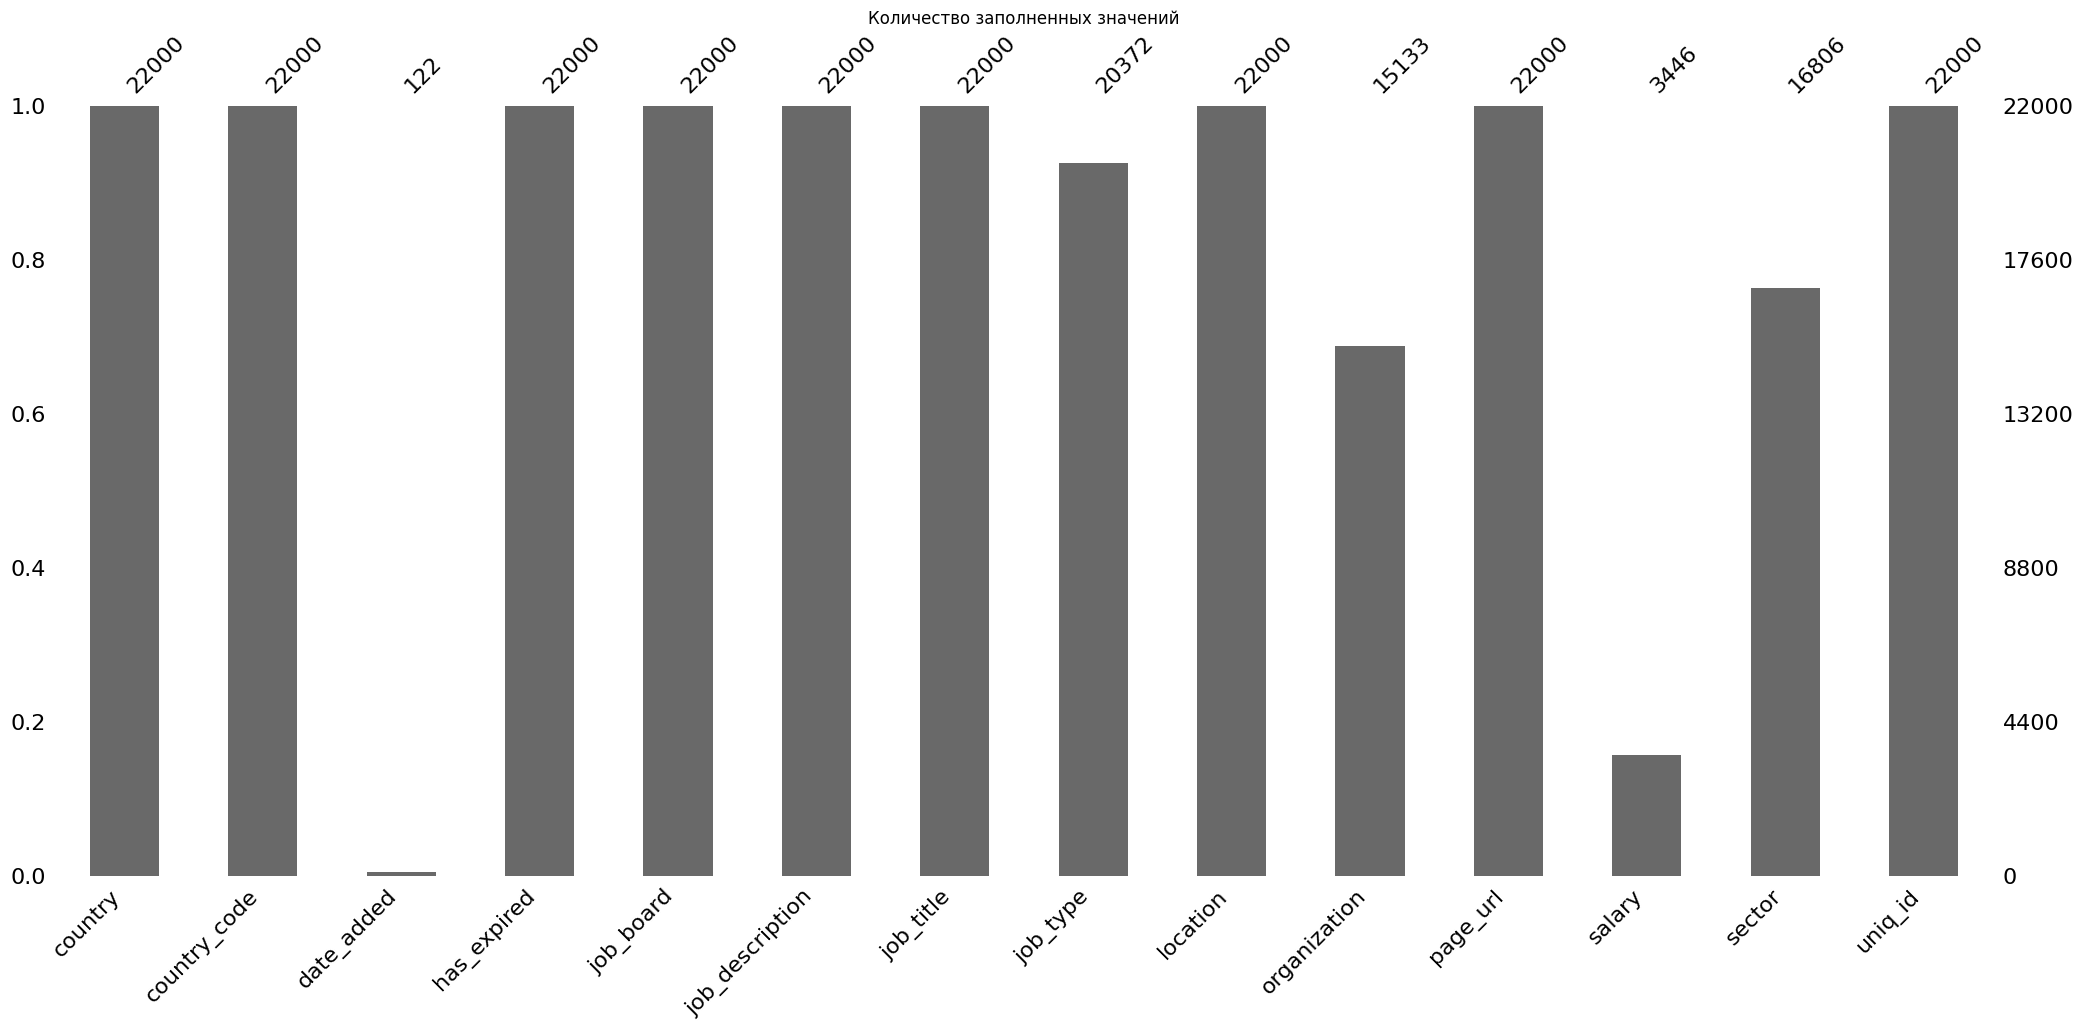

Количество строк с более чем 75% пропусков: 0
Исходный размер датасета: (22000, 14)
Размер после удаления строк с пропусками: (5, 14)


In [6]:
threshold = int(df.shape[1] * 0.75)

rows_with_many_missing = df[df.isna().sum(axis=1) > threshold]

msno.bar(df)

plt.title("Количество заполненных значений")
plt.show()

print("Количество строк с более чем 75% пропусков:",rows_with_many_missing.shape[0])

df_dropna = df.dropna()

print("Исходный размер датасета:", df.shape)
print("Размер после удаления строк с пропусками:", df_dropna.shape)

### Первичная оценка данных в столбцах

Изучите данные в столбцах датасета, ответив на следующие вопросы:
1. Есть ли столбцы, в которых встречается всего одно значение? Как их можно использовать в анализе?
2. Есть ли такие значения, которые встречаются более чем в одном столбце?
3. Есть ли столбцы, данные в которых не соответствуют названию столбца?

In [7]:
for col in df.columns:
    print(f"\n----- {col} -----")
    print("Количество уникальных значений:", df[col].nunique())
    print(df[col].value_counts(dropna=False).head(10))


----- country -----
Количество уникальных значений: 1
country
United States of America    22000
Name: count, dtype: int64

----- country_code -----
Количество уникальных значений: 1
country_code
US    22000
Name: count, dtype: int64

----- date_added -----
Количество уникальных значений: 78
date_added
NaN          21878
9/22/2016        6
3/21/2016        4
5/26/2016        4
7/7/2016         4
5/5/2016         3
6/3/2016         3
3/29/2016        3
4/29/2016        2
5/9/2016         2
Name: count, dtype: int64

----- has_expired -----
Количество уникальных значений: 1
has_expired
No    22000
Name: count, dtype: int64

----- job_board -----
Количество уникальных значений: 1
job_board
jobs.monster.com    22000
Name: count, dtype: int64

----- job_description -----
Количество уникальных значений: 18744
job_description
12N Horizontal Construction Engineers Job DescriptionAirfields. Roads. Dams. Buildings. Name the project, and the Army National Guard builds it. And to do it, they need 

### Дублирование данных

Для поиска дублирующихся строк выполните следующие действия:
1. В таблице есть столбец `uniq_id`, значения которого, как сказано в описании данных, являются уникальными идентификаторами записей. Проверьте, действительно ли в этом столбце все значения различны.
2. Проверьте, есть ли в таблице другие столбцы, значения которых в каждой строке различны.
3. Если игнорировать столбцы, где все значения различны, найдутся ли такие строки, для которых значения по всем остальным столбцам будут совпадать?

Оцените результаты поиска дубликатов.

In [8]:
print("Все ли значения uniq_id уникальны:")
print(df["uniq_id"].is_unique)

print("\nКоличество дубликатов uniq_id:")
print(df["uniq_id"].duplicated().sum())

Все ли значения uniq_id уникальны:
True

Количество дубликатов uniq_id:
0


In [9]:
unique_columns = []

for col in df.columns:
    if df[col].nunique() == len(df):
        unique_columns.append(col)

print("Столбцы с полностью уникальными значениями:")
print(unique_columns)

Столбцы с полностью уникальными значениями:
['page_url', 'uniq_id']


In [10]:
columns_without_unique = [col for col in df.columns if col not in unique_columns]

duplicates = df[df.duplicated(subset=columns_without_unique,keep=False)]

print("Количество дублирующихся строк:")
print(duplicates.shape[0])

Количество дублирующихся строк:
2078


# Практические задания

В этом разделе необходимо обработать значения в трех столбцах датасета: `location`, `salary` и `job_type`. Цель обработки – стандартизировать данные в каждом из столбцов так, чтобы их можно было анализировать.

### Задание 1

В задании 1 необходимо провести обработку столбца `location`.

#### Задание 1.1

В столбце `location` представлена информация о местоположении организации, в которой открыта вакансия. Каждое значение столбца `location` содержит информацию о городе, коде штата и почтовом индексе.

Однако не в каждой строке есть все три характеристики местоположения, а также могут встречаться разные комбинации из них, записанные в виде строки в произвольном порядке и с разными разделителями.

Например, может быть указан только код штата, только название города или только индекс. Могут быть указаны любые две характеристики из трех.

**Формулировка задания:**
1. Определите, какие форматы встречаются.
2. Напишите одно или несколько регулярных выражений для поиска выявленных форматов.
3. Визуализируйте количество найденных форматов на столбчатой или круговой диаграмме. Также покажите на ней количество строк, в которых формат определить не удалось. Какие форматы встречаются чаще всего?

Ознакомиться с теоретическим материалом по работе с регулярными выражениями можно [по ссылке](https://colab.research.google.com/drive/1eFHdmt9OROLEDJRNc2wNmz0gpE1O3sKU?usp=sharing).

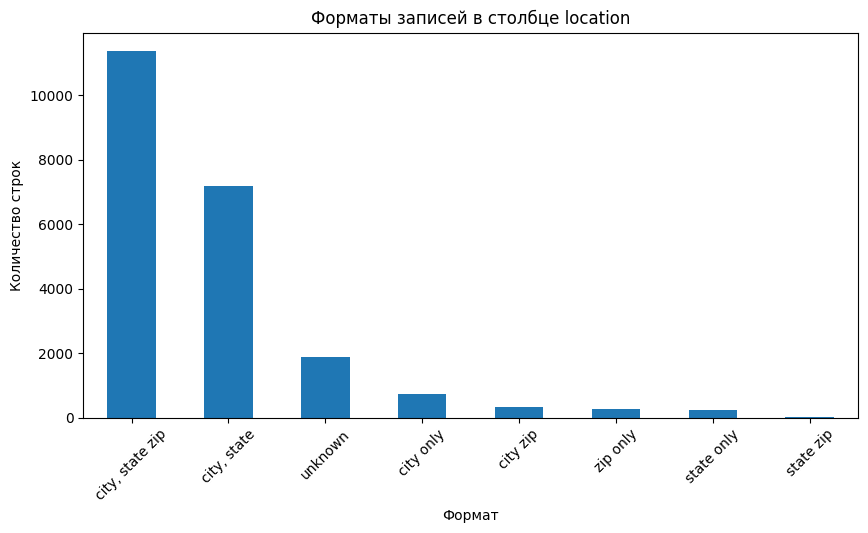

In [11]:

df["location"].value_counts().head(30)

# Функция для определения формата location

def detect_location_format(value):
    value = str(value).strip()

    city = r"[A-Za-z .'-]+"
    state = r"[A-Z]{2}"
    zip_code = r"\d{5}"

    if re.fullmatch(fr"{city},\s*{state}\s+{zip_code}", value):
        return "city, state zip"

    elif re.fullmatch(fr"{city},\s*{state}", value):
        return "city, state"

    elif re.fullmatch(fr"{state}\s+{zip_code}", value):
        return "state zip"

    elif re.fullmatch(fr"{city}\s+{zip_code}", value):
        return "city zip"

    elif re.fullmatch(state, value):
        return "state only"

    elif re.fullmatch(zip_code, value):
        return "zip only"

    elif re.fullmatch(city, value):
        return "city only"

    else:
        return "unknown"

df["location_format"] = df["location"].apply(detect_location_format)

df["location_format"].value_counts()

plt.figure(figsize=(10, 5))

df["location_format"].value_counts().plot(kind="bar")

plt.title("Форматы записей в столбце location")
plt.xlabel("Формат")
plt.ylabel("Количество строк")
plt.xticks(rotation=45)
plt.show()

#### Задание 1.2

В большей части строк удалось извлечь данные из ячейки столбца `location`, но остались и такие, где это не получилось. Вынесите в отдельный датасет записи, в которых не удалось определить формат записи информации о местоположении.

Над оставшимися строками проведите следующие преобразования:
1. Данные о местоположении разделите на 3 столбца: город, код штата, почтовый индекс.
2. Так как значения в столбце `почтовый индекс` являются пятизначными числами, преобразуйте их в целочисленный формат.

In [12]:
# Отдельный датасет для строк, где формат location определить не удалось

location_unknown = df[df["location_format"] == "unknown"].copy()

print("Количество строк с неизвестным форматом:", location_unknown.shape[0])
location_unknown[["location"]].head(20)

Количество строк с неизвестным форматом: 1888


,location
2,"DePuy Synthes Companies is a member of Johnson & Johnson's Family of Companies, and is recruiting for a Senior Train..."
29,"Sr. Process Engineer, Manufacturing"
36,"RF System Technician, Field Service"
44,"Bradford, Vt 05033"
45,Respiratory Therapist PRN Nights - Kindred Hospital Medical Center ( Job Number: 266123 ) Description IT'S SIMPLE. Y...
72,"""Statewide"", CO"
105,Registered Nurse ICU Full Time Days - Kindred Hospital Town and Country ( Job Number: 259725 ) Description IT'S SIMP...
115,Experienced Registered Nurse-Critical Care/ICU - Float Pool - Kindred Hospitals - Houston Texas Area ( Job Number: 2...
135,"Bafb, Aurora 80011"
138,Registered Nurse ICU Full Time Nights - Kindred Hospital Town and Country ( Job Number: 254990 ) Description IT'S SI...


Рассмотрите отложенную часть выборки (ту, где не удалось данные из столбца `location` разделить на три поля) и сделайте выводы о возможности извлечь из данных город, код штата и почтовый индекс. Извлеките все, что возможно. Что невозможно – оставьте пустым.

In [14]:
def extract_location(value):
    value = str(value).strip()

    city = np.nan
    state = np.nan
    zip_code = np.nan

    state_match = re.search(r"\b[A-Z]{2}\b", value)
    zip_match = re.search(r"\b\d{5}\b", value)

    if state_match:
        state = state_match.group()

    if zip_match:
        zip_code = zip_match.group()

    city_part = re.sub(r"\b[A-Z]{2}\b", "", value)
    city_part = re.sub(r"\b\d{5}\b", "", city_part)
    city_part = city_part.replace(",", " ").strip()
    city_part = re.sub(r"\s+", " ", city_part)

    if city_part:
        city = city_part

    return pd.Series([city, state, zip_code])

### Задание 2

В задании 2 необходимо провести обработку столбца `salary`.

#### Задание 2.1

В столбце `salary`, как и в `location`, данные не стандатизированы. В нем в основном можно встретить записи в следующих форматах:

* 10.00 - 20.00 &dollar; &sol;hour
* 10,000.00 - 20,000.00 &dollar; &sol;year
* &dollar;10.00 &sol;hour
* &dollar;10,000.00+ &sol;year
* Up to &dollar;20,000.00

Основные проблемы, которые стоит учесть при обработке форматов:
- В каждом из форматов может быть или не быть знака доллара.
- Может отсутствовать информация о периоде, за который указывается зарплата (`/hour` или `/year` в примерах).
- Зарплата может быть указана за месяц (`/month`) и за неделю (`/week`).
- В начале, конце и середине некоторых строк есть лишние пробелы, которые не стоит учитывать.

**Задание:**
1. Определите весь перечень встречающихся форматов и напишите одно или несколько регулярных выражений для их поиска.
2. Покажите на столбчатой диаграмме количество записей, содержащих каждый из форматов. Сделайте выводы.

In [15]:
df["salary"].value_counts(dropna=False).head(30)

def detect_salary_format(value):
    if pd.isna(value):
        return "missing"

    value = str(value).strip()

    money = r"\$?\s*\d[\d,]*(?:\.\d+)?"
    period = r"/\s*(hour|year|month|week)"

    if re.fullmatch(fr"{money}\s*-\s*{money}\s*\$?\s*{period}?", value, flags=re.I):
        return "range"

    elif re.fullmatch(fr"{money}\+?\s*{period}?", value, flags=re.I):
        return "single value"

    elif re.fullmatch(fr"Up to\s+{money}\s*{period}?", value, flags=re.I):
        return "up to"

    else:
        return "unknown"

#### Задание 2.2

1. Разделите столбец `salary` зарплаты три: `минимальная граница зарплаты`, `максимальная граница зарплаты`, `период`. Если значение суммы указано только одно, считайте, что это минимальная зарплата. Значение суммы в обоих столбцах преобразуйте в формат `float`.
2. Покажите на столбчатой диаграмме с группировкой среднюю и медианную минимальную зарплату в каждом периоде. Сделайте выводы.

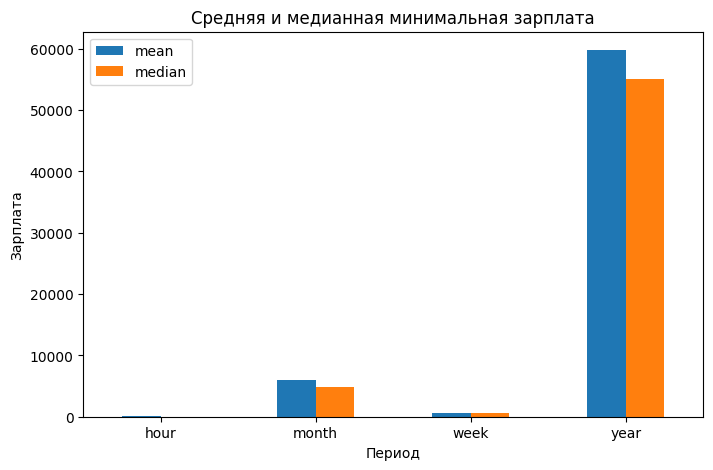

In [19]:
def parse_salary(value):

    if pd.isna(value):
        return pd.Series([np.nan, np.nan, np.nan])

    value = str(value).strip()

    # Период
    period_match = re.search(r"/\s*(hour|year|month|week)", value, flags=re.I)

    period = np.nan

    if period_match:
        period = period_match.group(1).lower()

    # Все найденные числа
    numbers = re.findall(r"\d[\d,]*(?:\.\d+)?", value)

    numbers = [float(num.replace(",", ""))for num in numbers]

    salary_min = np.nan
    salary_max = np.nan

    if len(numbers) == 1:
        salary_min = numbers[0]

    elif len(numbers) >= 2:
        salary_min = numbers[0]
        salary_max = numbers[1]

    return pd.Series([salary_min, salary_max, period])

df[["salary_min", "salary_max", "salary_period"]] = (df["salary"].apply(parse_salary))

df[["salary","salary_min","salary_max","salary_period"]].sample(20, random_state=42)

salary_stats = df.groupby("salary_period")["salary_min"].agg(["mean", "median"])

salary_stats.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Средняя и медианная минимальная зарплата")
plt.xlabel("Период")
plt.ylabel("Зарплата")

plt.xticks(rotation=0)
plt.show()

#### Задание 2.3

Как было отмечено в задании 2.1, период, за который указывается зарплата, может отсутствовать. Восполните этот пробел в данных следующим образом:

1. Определите диапазон изменения (разброс) значений денежной суммы за каждый из встречающихся в данных периодов. Постройте гистограмму для каждого периода.
2. Определите, к среднему значению за какой период ближе всего сумма, у которой период не указан. Укажите для найденный период. В спорных случаях, где сумма одинаково близка к нескольким диапазонам, не выбирайте ничего.

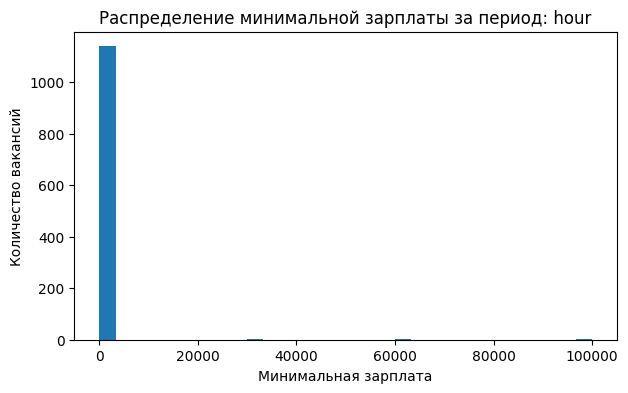

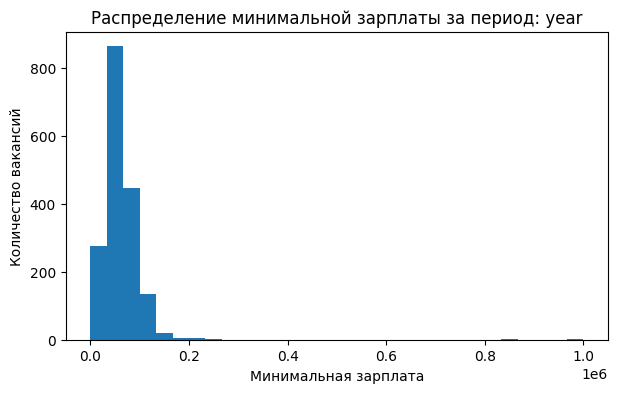

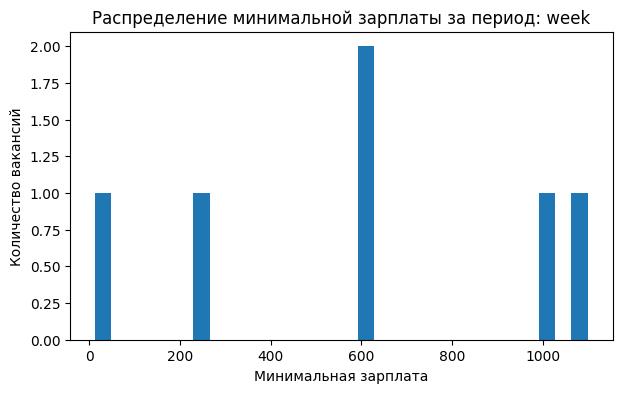

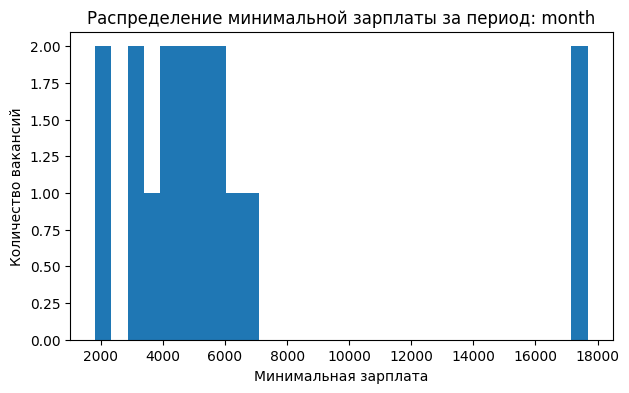

,salary,salary_min,salary_period,salary_period_filled
13035,NaN,NaN,NaN,NaN
3115,NaN,NaN,NaN,NaN
8732,NaN,NaN,NaN,NaN
7591,NaN,NaN,NaN,NaN
221,NaN,NaN,NaN,NaN
17295,NaN,NaN,NaN,NaN
5857,NaN,NaN,NaN,NaN
12608,NaN,NaN,NaN,NaN
3463,NaN,NaN,NaN,NaN
6478,NaN,NaN,NaN,NaN


In [21]:
# Диапазоны зарплат по периодам

period_ranges = df.groupby("salary_period")["salary_min"].agg(
    ["count", "min", "max", "mean", "median"]
)

period_ranges

for period in df["salary_period"].dropna().unique():
    data = df[
        (df["salary_period"] == period) &
        (df["salary_min"].notna())
    ]

    plt.figure(figsize=(7, 4))
    plt.hist(data["salary_min"], bins=30)

    plt.title(f"Распределение минимальной зарплаты за период: {period}")
    plt.xlabel("Минимальная зарплата")
    plt.ylabel("Количество вакансий")

    plt.show()


period_means = df.groupby("salary_period")["salary_min"].mean()

def fill_salary_period(row):
    if pd.notna(row["salary_period"]):
        return row["salary_period"]

    if pd.isna(row["salary_min"]):
        return np.nan

    differences = abs(period_means - row["salary_min"])
    min_difference = differences.min()

    closest_periods = differences[
        differences == min_difference
    ].index.tolist()

    if len(closest_periods) == 1:
        return closest_periods[0]
    else:
        return np.nan

df["salary_period_filled"] = df.apply(fill_salary_period, axis=1)

df[["salary", "salary_min", "salary_period", "salary_period_filled"]].sample(20, random_state=42)

### Задание 3

В задании 3 необходимо провести обработку столбца `job_type`. Выясните, какие форматы значений есть в столбце `job_type`. Сделайте выводы. При необходимости – стройте графики.

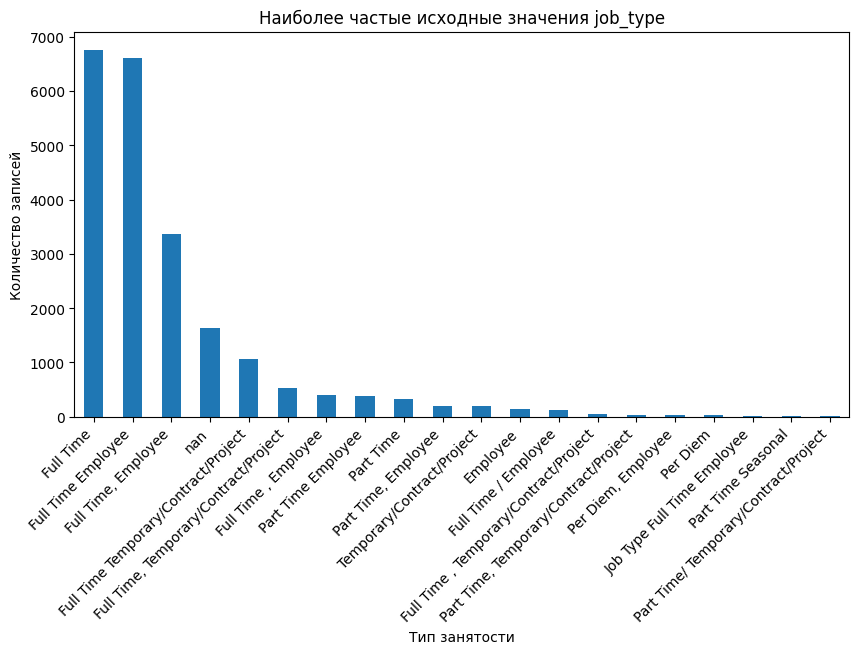

In [22]:
df["job_type"].value_counts(dropna=False).head(30)

plt.figure(figsize=(10, 5))

df["job_type"].value_counts(dropna=False).head(20).plot(kind="bar")

plt.title("Наиболее частые исходные значения job_type")
plt.xlabel("Тип занятости")
plt.ylabel("Количество записей")
plt.xticks(rotation=45, ha="right")
plt.show()

Вы заметили, что многие значения фактически одинаковые, но немного по-разному отформатированы? Приведем их к единому формату.

In [23]:
def normalize_job_type(value):
    if pd.isna(value):
        return np.nan

    value = str(value).strip()

    # Убираем лишние пробелы вокруг запятых
    value = re.sub(r"\s*,\s*", ", ", value)

    # Убираем повторяющиеся пробелы
    value = re.sub(r"\s+", " ", value)

    return value


df["job_type_clean"] = df["job_type"].apply(normalize_job_type)

df["job_type_clean"].value_counts(dropna=False).head(30)

,count
job_type_clean,
Full Time,6771
Full Time Employee,6618
"Full Time, Employee",3766
NaN,1628
Full Time Temporary/Contract/Project,1062
"Full Time, Temporary/Contract/Project",589
Part Time Employee,382
Part Time,330
"Part Time, Employee",200


Столбец `job_type` состоит из двух частей: "полнота" занятости (`Full Time`, `Part Time`, `Per Diem`) и "тип" занятости (`Employee`, `Intern`). Кроме того, встречаются и неполные записи.

Задание:
1. Написать одно или несколько регулярных выражений для разделения столбца `job_type` на два: `полнота занятости`, `тип занятости`.
2. Если данные о полноте отсутствуют, внесите значение `Full Time`.
Если отсутствуют данные о типе – внесите `Employee`.
3. Постройте столбчатую диаграмму со стековой группировкой для полноты и типа занятости. Сделайте выводы.

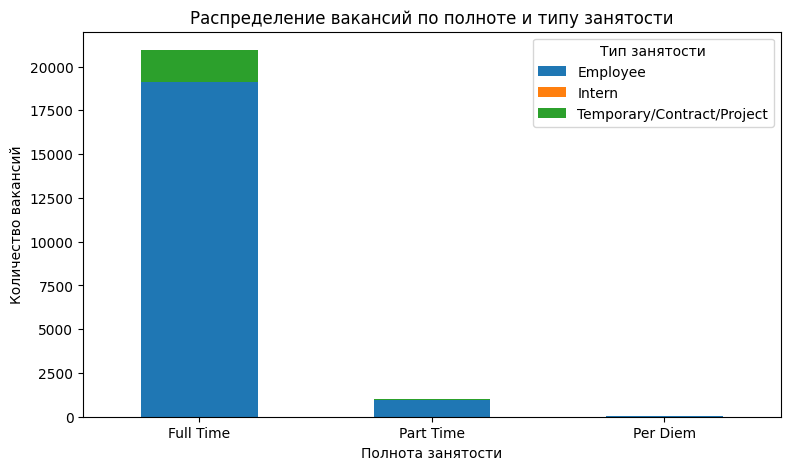

In [24]:
def split_job_type(value):
    if pd.isna(value):
        return pd.Series(["Full Time", "Employee"])

    value = str(value).strip()

    fullness = np.nan
    emp_type = np.nan

    # Полнота занятости
    if re.search(r"Full\s*Time", value, flags=re.I):
        fullness = "Full Time"
    elif re.search(r"Part\s*Time", value, flags=re.I):
        fullness = "Part Time"
    elif re.search(r"Per\s*Diem", value, flags=re.I):
        fullness = "Per Diem"

    # Тип занятости
    if re.search(r"Employee", value, flags=re.I):
        emp_type = "Employee"
    elif re.search(r"Intern", value, flags=re.I):
        emp_type = "Intern"
    elif re.search(r"Temporary|Contract|Project", value, flags=re.I):
        emp_type = "Temporary/Contract/Project"

    # По условию задания
    if pd.isna(fullness):
        fullness = "Full Time"

    if pd.isna(emp_type):
        emp_type = "Employee"

    return pd.Series([fullness, emp_type])

df[["employment_fullness", "employment_type"]] = (df["job_type_clean"].apply(split_job_type))

df[["job_type", "job_type_clean", "employment_fullness", "employment_type"]].sample(20, random_state=42)

job_type_table = pd.crosstab(df["employment_fullness"], df["employment_type"])

job_type_table


job_type_table.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5)
)

plt.title("Распределение вакансий по полноте и типу занятости")
plt.xlabel("Полнота занятости")
plt.ylabel("Количество вакансий")
plt.xticks(rotation=0)
plt.legend(title="Тип занятости")
plt.show()

В столбце job_type значения записаны в разных форматах. Например, встречаются варианты Full Time Employee, Full Time, Employee, Full Time , Employee, которые фактически обозначают одно и то же. Также есть пропущенные значения и неполные записи.

Если полнота занятости отсутствовала, было указано значение Full Time. Если отсутствовал тип занятости, было указано значение Employee.

Наиболее часто встречаются вакансии с полной занятостью и типом Employee. Также встречаются временные, контрактные и проектные вакансии, а доля стажировок значительно меньше.

# Порядок защиты работы

**Для защиты работы необходимо:**
1. Предоставить результаты выполнения всех заданий в виде ссылки на Google Colab.
2. Выполнить дополнительное задание в процессе сдачи работы. Дополнительное задание представляет собой решение задачи на обработку данных лабораторной работы, меньшее по объему, но сопоставимое по сложности тем заданиям, которые требовалось выполнить в рамках работы.

**Примеры дополнительных заданий:**
1. В столбце `sector` часто представлены данные из столбца `organization` и наоборот. Устраните эту проблему.
2. В столбце `job_title` часто можно частично или полностью встретить указание местоположения организации. Сравните, совпадают ли в таких случаях данные с тем, что указано в столбцах `город`, `код штата`, `почтовый индекс`. Если в этих трех столбцах данные отсутствуют, заполните их данными из столбца `job_title`.
3. Практически во всех столбцах датасета вместо соответствующих названию данных иногда встречается текст из `job_description`. Найдите такие столбцы и записи с описанием вакансии в них. Покажите на столбчатой диаграмме, в каких столбцах и в каком количестве находится информация из столбца `job_description`.

# Дополнительные материалы

1. DAMA-DMBOK: Свод знаний по управлению данными: Второе издание / DAMA International; [пер. с англ.]. – Москва: ООО "Олимп-Бизнес", 2021. – 828 с.
2. Макгрегор, С. Обработка данных на Python: Data Wrangling и Data Quality: [Текст] / С. Макгрегор. – Москва: БХВ, 2024. – 432 с.